## M1: Split the Data

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error


clean_data = pd.read_csv('/Users/laven/Documents/TKH/-citibike-ridership-model-/Data/citibike_weather_daily_clean.csv')

from sklearn.model_selection import train_test_split


x = clean_data.drop(columns=['ride_date'])
y = clean_data['num_rides']


x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42
)

print(f"Training set features: {x_train.shape}, target: {y_train.shape}")
print(f"Testing set features:  {x_test.shape}, target: {y_test.shape}")

Training set features: (1287, 11), target: (1287,)
Testing set features:  (322, 11), target: (322,)


## M2: Fit the Core Model

In [18]:

clean_data['ride_date'] = pd.to_datetime(clean_data['ride_date'])
clean_data['trend'] = (clean_data['ride_date'] - clean_data['ride_date'].min()).dt.days
df = pd.get_dummies(clean_data, columns=['day_of_week'], drop_first=True)

feature_columns = [
    'temp_f',
    'precip_in',
    'wind_speed_knots',
    'trend'
] + [col for col in df.columns if col.startswith('day_of_week_')]

X = df[feature_columns]
y = df['num_rides']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model = LinearRegression()
model.fit(x_train, y_train)

coefficients = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(f"Intercept: {model.intercept_:.2f}\n")
print(coefficients.to_string(index=False))

Intercept: -9397.32

              Feature  Coefficient
day_of_week_Wednesday  1773.964654
 day_of_week_Thursday  1596.650478
  day_of_week_Tuesday   964.233063
               temp_f   573.575052
                trend    16.442116
     wind_speed_knots  -335.600439
   day_of_week_Monday -1407.877296
            precip_in -3656.304363
 day_of_week_Saturday -5324.377814
   day_of_week_Sunday -6559.333219


## M3: Evaluate

In [19]:
train_r_squared = model.score(x_train, y_train)
test_r_squared = model.score(x_test, y_test)

print(f"Training R squared: {train_r_squared:.4f}")
print(f"Testing R squared:  {test_r_squared:.4f}")

y_test_prediction = model.predict(x_test)

test_mae = mean_absolute_error(y_test, y_test_prediction)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_prediction))

print(f"Test MAE:  {test_mae:,.2f} rides")
print(f"Test RMSE: {test_rmse:,.2f} rides")

Training R squared: 0.7268
Testing R squared:  0.7588
Test MAE:  6,660.10 rides
Test RMSE: 8,345.34 rides



Testing R² = 0.7588 determines how much variation in the dependent variable is expained by the model. In this case, it is 75.88%. The training model actually learned the trends in the data.

Our prediction is typically off by about 6,660 rides. The gap between the MAE and  RMSE is not very wide, the total error is dominated by a few badly-missed days. The suspect days are thanksgiving or major holidays or weekends.



## M4: Interpret the Coefficients

In [20]:
coefficients = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(f"Intercept: {model.intercept_:.2f}\n")
print(coefficients.to_string(index=False))

Intercept: -9397.32

              Feature  Coefficient
day_of_week_Wednesday  1773.964654
 day_of_week_Thursday  1596.650478
  day_of_week_Tuesday   964.233063
               temp_f   573.575052
                trend    16.442116
     wind_speed_knots  -335.600439
   day_of_week_Monday -1407.877296
            precip_in -3656.304363
 day_of_week_Saturday -5324.377814
   day_of_week_Sunday -6559.333219



Each additional inch of rain costs us roughly 3,656 rides. On Sunday ride deman drops by roughly  6559 rides.For every 1 degree increase in temperature, we gain roughly 5,736 rides.

## M5: Diagnose With Residuals

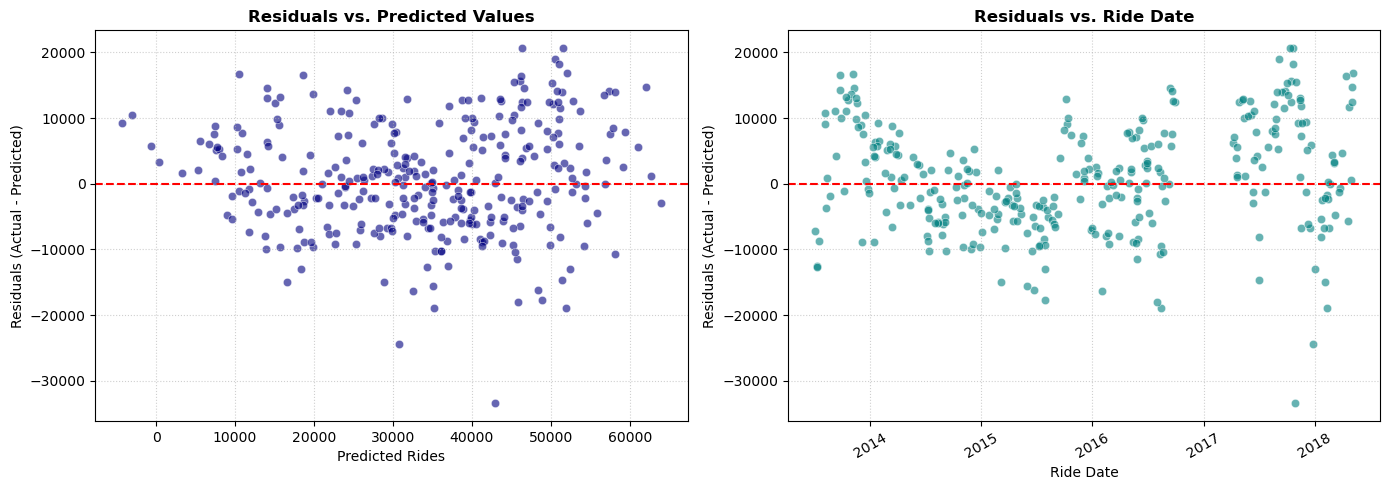

In [21]:
y_prediction = model.predict(x_test)
residuals = y_test - y_prediction

test_dates = clean_data.loc[x_test.index, 'ride_date']


plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
sns.scatterplot(x=y_prediction, y=residuals, alpha=0.6, color='navy')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residuals vs. Predicted Values', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Rides', fontsize=10)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
sns.scatterplot(x=test_dates, y=residuals, alpha=0.6, color='teal')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residuals vs. Ride Date', fontsize=12, fontweight='bold')
plt.xlabel('Ride Date', fontsize=10)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=10)
plt.xticks(rotation=30)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## M6: Improve One Thing

## M7: The Write-Up

